In [1]:
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt

In [2]:
K = np.random.randint(2,7)
print(f'Number of bits to be transmitted in the given message: {K}')
ita = np.random.uniform(0,0.5)
print(f'Coefficient (side lobe) of Autocorrelation Polynomial: {ita}')

discriminant = np.sqrt(1-4*ita**2)
Ro = (1 + discriminant) / (2 * ita)
Ri = (1 - discriminant) / (2 * ita)

print(f"Outer radius of circle: {Ro}")
print(f"Inner radius of circle: {Ri}")

arc_width = np.pi * 2 / K

theta_k = [( arc_width * k + np.pi/4) for k in range(0,K)]
print(f'Sectors selected using fundamantal spacing (period) {theta_k}')

Number of bits to be transmitted in the given message: 4
Coefficient (side lobe) of Autocorrelation Polynomial: 0.12565790238308205
Outer radius of circle: 7.830407423252125
Inner radius of circle: 0.1277072757453888
Sectors selected using fundamantal spacing (period) [0.7853981633974483, 2.356194490192345, 3.9269908169872414, 5.497787143782138]


In [3]:
zeros = [(Ri * np.exp(1j * t), Ro * np.exp(1j * t)) for t in theta_k]

print(f'Zeros derived from the Huffman autocorrelation: ')
for i in zeros:
    print(np.round(i, 5))

Zeros derived from the Huffman autocorrelation: 
[0.0903 +0.0903j  5.53693+5.53693j]
[-0.0903 +0.0903j  -5.53693+5.53693j]
[-0.0903 -0.0903j  -5.53693-5.53693j]
[0.0903 -0.0903j  5.53693-5.53693j]


In [4]:
message = [np.random.randint(2) for mk in range(K)]
print(f'Message bits to be transmitted: {message}')

Message bits to be transmitted: [0, 0, 1, 0]


In [5]:
def toeplitz_iterator(K, msg, zer):

    tx_zeros = np.zeros(len(msg), dtype=complex)
    for i in range(len(msg)):
        alpha = zer[i][msg[i]]
        tx_zeros[i] = alpha
        
        # print(f'Selected Zero is: {alpha}')
        if i == 0:
            c = np.array([[1, -alpha]]).T   # (z-alpha)
        else:
            col = np.zeros(i + 2, dtype=complex)
            # print(c)
            col[0] = 1
            col[1] = -alpha

            row = np.zeros(i + 1, dtype=complex)

            T = toeplitz(col,row)

            c = T @ c

    # print(c)
    # print(tx_zeros)
    return c.flatten(), tx_zeros


In [6]:
x, tx_zeros = toeplitz_iterator(K, message, zeros)
print('Polynomial coefficients to be transmitted:')
print(np.round(x, 5))

# print(tx_zeros)

Polynomial coefficients to be transmitted:
[ 1.     +0.j       5.44663+5.44663j -0.     -0.98369j -0.08883+0.08883j
  0.01631-0.j     ]


In [7]:
# col = np.zeros(3, dtype=complex)
# col[0] = 1
# col[1] = -1
# row = np.zeros(4, dtype=complex)
# row[0] = 1

# print(toeplitz(col, row))

# h = [1] + [2]
# print(h)

# print(np.random.uniform(0,1))
print(np.random.randn())

-1.3372562942656727


In [8]:
L = K
print(f"Number of multipath fading channels: {L}")
path_var = np.random.uniform(0,1)
h = [( np.sqrt(0.5 * path_var**i) * np.random.rand() + 1j * np.sqrt(0.5 * path_var**i) * np.random.rand()) for i in range(L)]
h = np.array(h)
print(f'Number of taps in channel: {len(h)}')
print('Filter coefficients: ')
print(np.round(h, 5))

Number of multipath fading channels: 4
Number of taps in channel: 4
Filter coefficients: 
[0.59734+0.23672j 0.43307+0.47552j 0.06758+0.40307j 0.26458+0.28032j]


In [9]:
y = np.convolve(x, h)

print(f'Length of the received symbol: {len(y)}\n')
print('received coefficients of the polynomial: ')
print(np.round(y, 6))

received_zeros = np.roots(y)
print(f"\nReceived zeros: {np.round(received_zeros, 6)}")

print(f"\nTransmitted zeros: {np.round(tx_zeros, 6)}")

Length of the received symbol: 8

received coefficients of the polynomial: 
[ 0.597344+2.367240e-01j  2.397237+5.018380e+00j  0.069248+4.764257e+00j
 -1.169036+2.449820e+00j  0.239794+2.901446e+00j  0.241001-2.823070e-01j
 -0.047301+5.175000e-03j  0.004315+4.572000e-03j]

Received zeros: [-5.536934-5.536934j -1.058902-0.093586j  0.22522 -0.93138j
 -0.065566+0.585272j  0.090303-0.090303j  0.090303+0.090303j
 -0.090303+0.090303j]

Transmitted zeros: [ 0.090303+0.090303j -0.090303+0.090303j -5.536934-5.536934j
  0.090303-0.090303j]


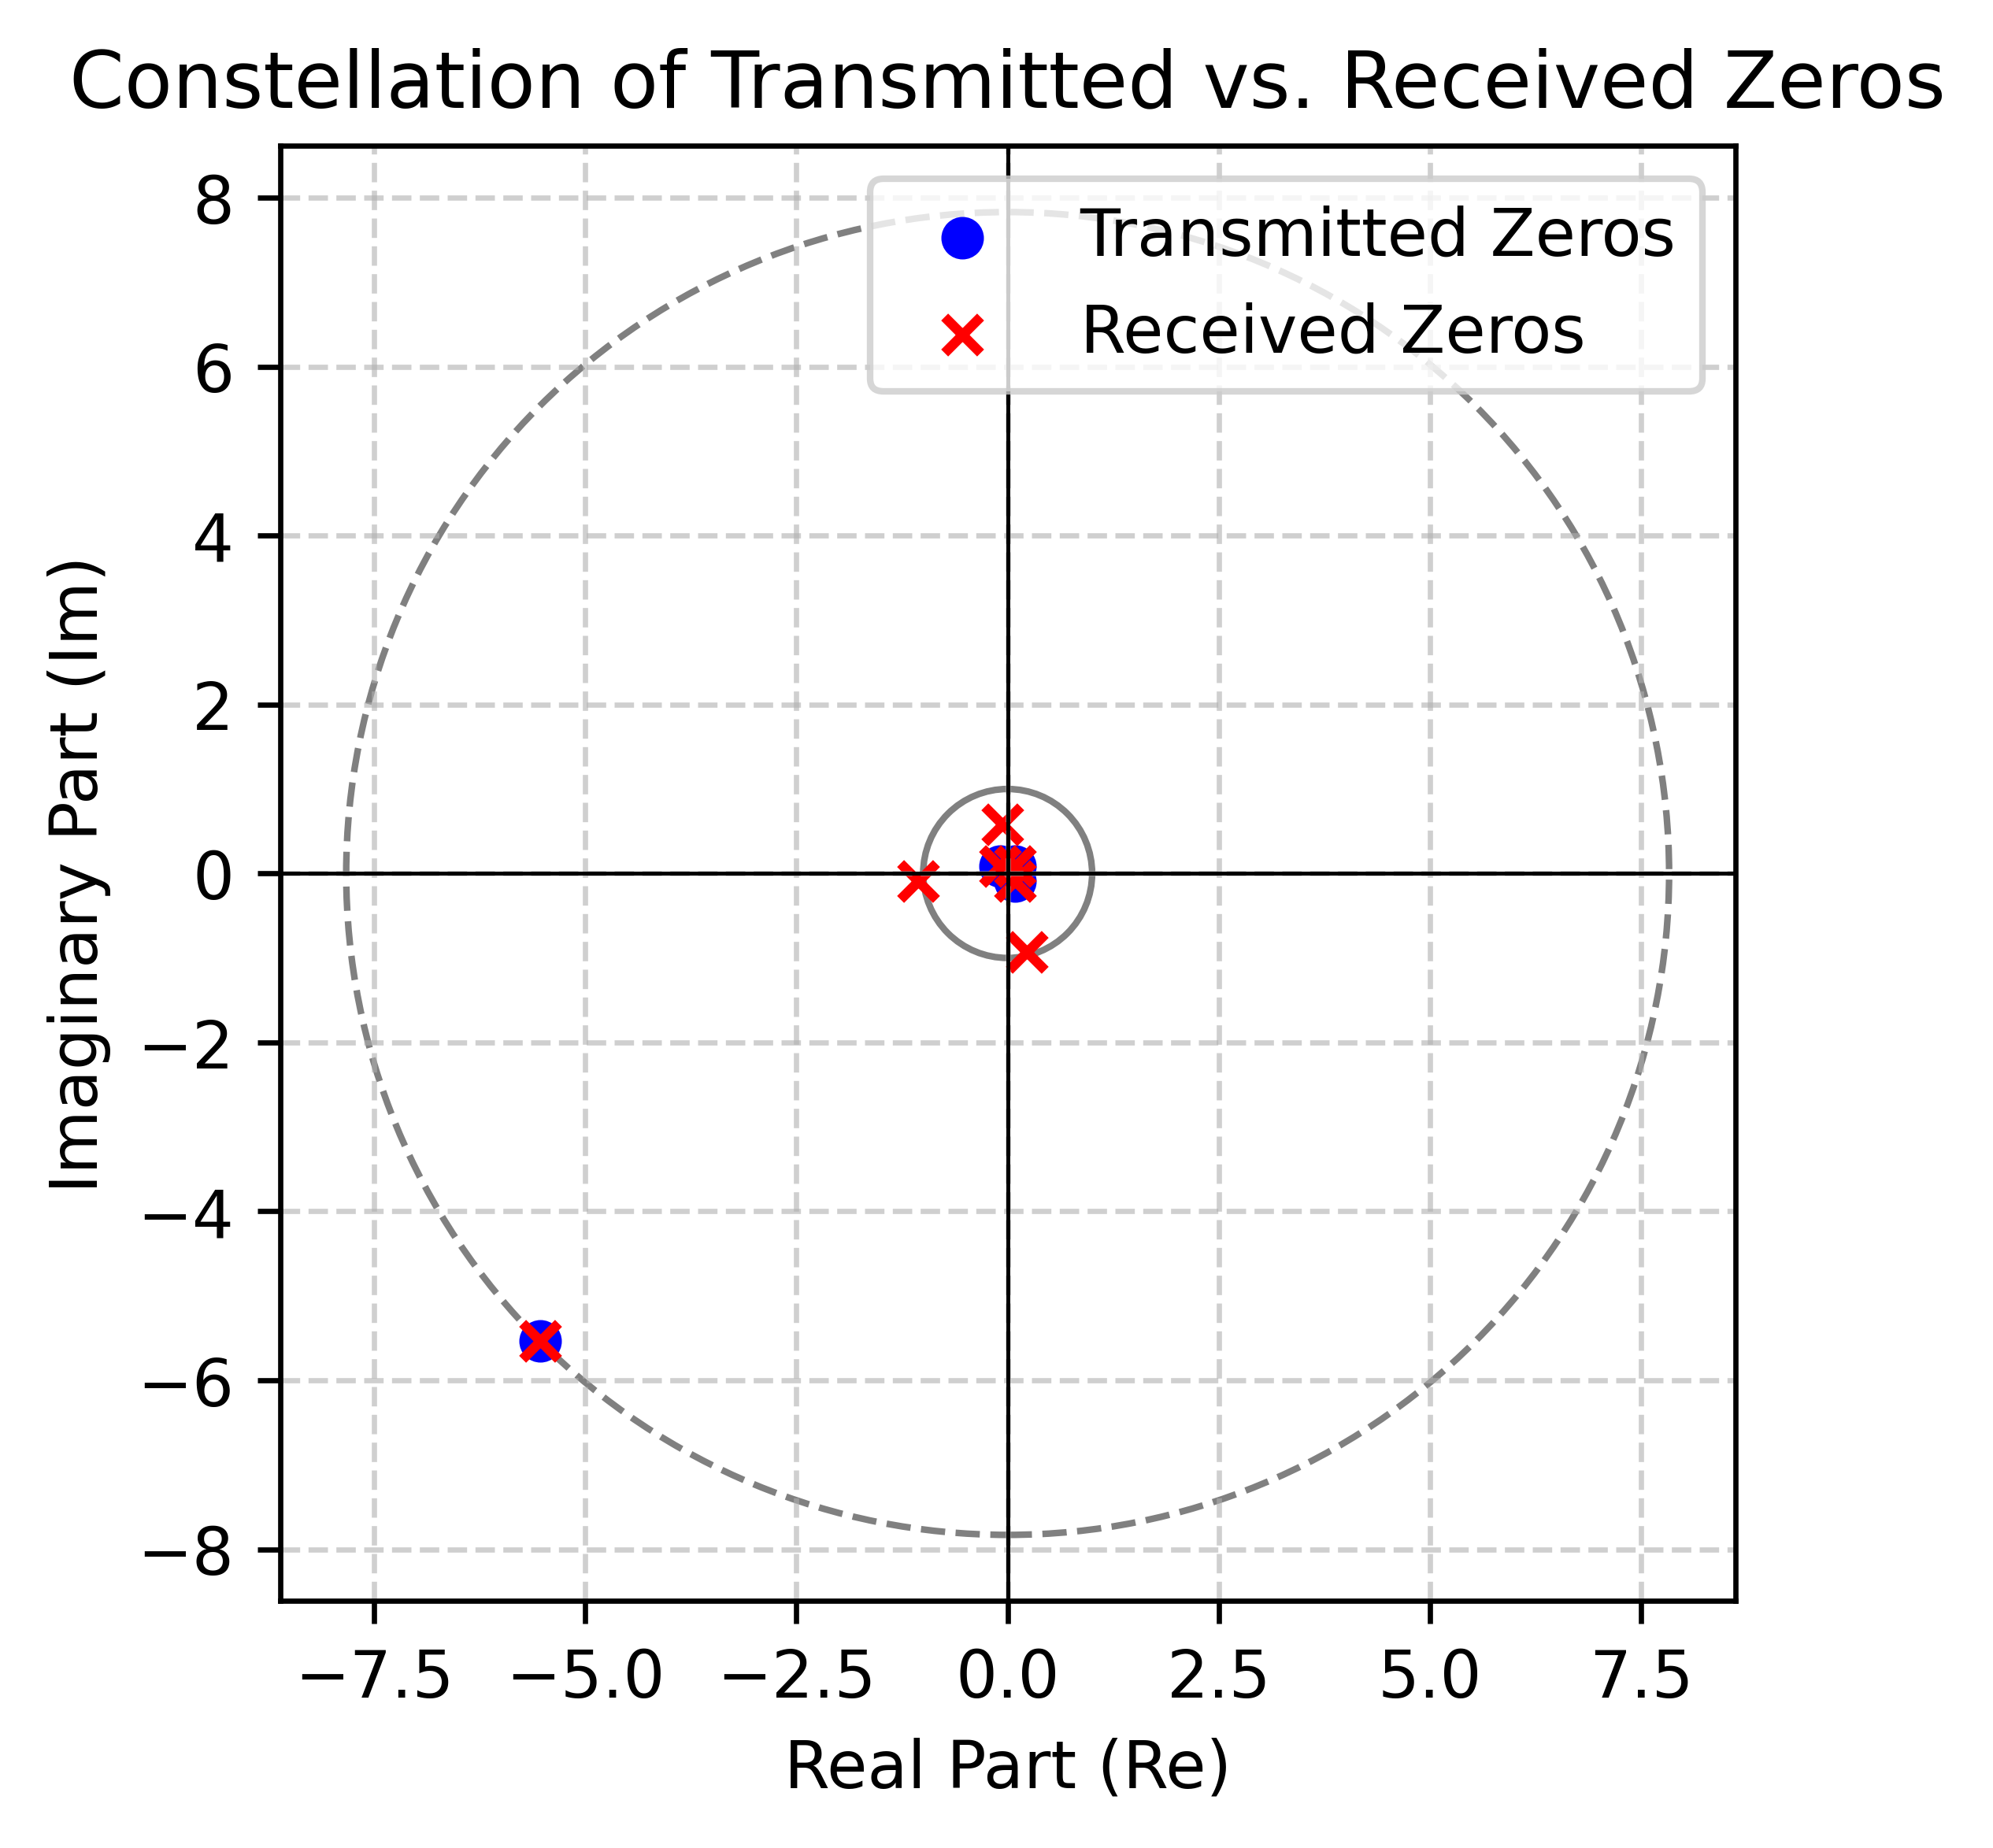

In [10]:
fig, ax = plt.subplots(figsize=(4,4), dpi=600)

circle1 = plt.Circle((0,0), radius=1, color='gray', fill=False, linestyle='-')
circle2 = plt.Circle((0,0), radius=Ri, color='gray', fill=False, linestyle='--')
circle3 = plt.Circle((0,0), radius=Ro, color='gray', fill=False, linestyle='--')

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

ax.scatter(tx_zeros.real, tx_zeros.imag, color='blue', marker='o', s=30, label='Transmitted Zeros')
ax.scatter(received_zeros.real, received_zeros.imag, color='red', marker='x', s=30, label='Received Zeros')

ax.set_aspect('equal', adjustable='box')

ax.axhline(0, color='black', linewidth=.6)
ax.axvline(0, color='black', linewidth=.6)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel('Real Part (Re)')
ax.set_ylabel('Imaginary Part (Im)')
ax.set_title('Constellation of Transmitted vs. Received Zeros')
ax.legend(loc='upper right')

plt.show()

In [11]:
N = (K+1) + L - 1
eps = 3e-7
SNR = 30    # in dB
sign_energy = N
sig_power = sign_energy / N

noise_power = 10 ** (-SNR/10)
print(f"Noise variance(complex): {noise_power}")

n_var_bound = eps**2/N
print(f"Noise variance bound: {n_var_bound}")

Noise variance(complex): 0.001
Noise variance bound: 1.125e-14


In [12]:
w = [ np.sqrt(noise_power/2)*np.random.randn() + 1j*np.sqrt(noise_power/2)*np.random.randn() for i in range(N)]

# print(np.round(w, 6))
y_noise = np.convolve(x, h) + w

received_zeros_noise = np.roots(y_noise)
print(f"\nReceived zeros: {np.round(received_zeros_noise, 6)}")

print(f"\nTransmitted zeros: {np.round(tx_zeros, 6)}")

# print(y_noise)
# print(np.convolve(x,h))


Received zeros: [-5.255775-5.840294j -1.053687-0.086793j  0.228495-0.940079j
 -0.064681+0.509746j -0.012187+0.378508j  0.273796-0.079908j
 -0.175369-0.129218j]

Transmitted zeros: [ 0.090303+0.090303j -0.090303+0.090303j -5.536934-5.536934j
  0.090303-0.090303j]


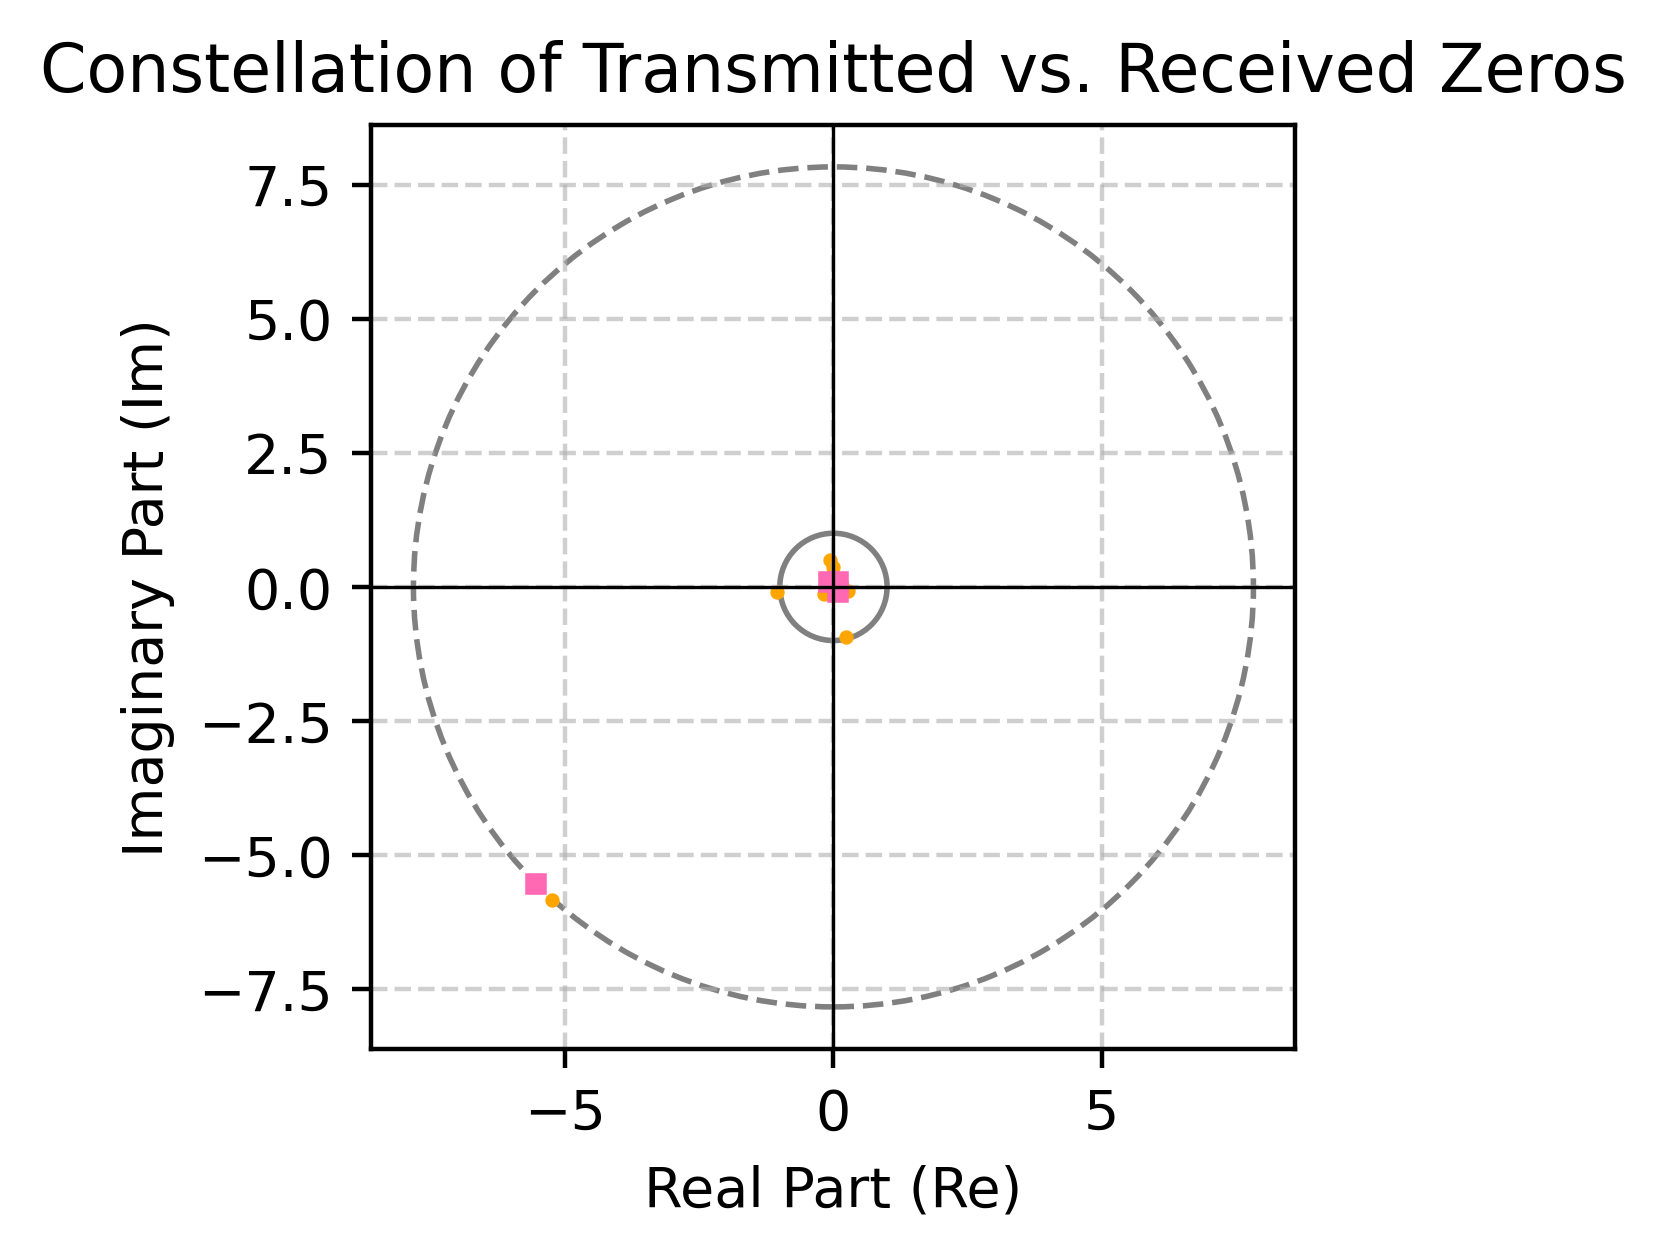

In [28]:
fig, ax = plt.subplots(figsize=(3,3), dpi=400)

circle1 = plt.Circle((0,0), radius=1, color='gray', fill=False, linestyle='-')
circle2 = plt.Circle((0,0), radius=Ri, color='gray', fill=False, linestyle='--')
circle3 = plt.Circle((0,0), radius=Ro, color='gray', fill=False, linestyle='--')

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

ax.plot(tx_zeros.real, tx_zeros.imag, marker='s', markerfacecolor='hotpink',
            markeredgecolor='hotpink', linestyle='none', markersize=3)
ax.scatter(received_zeros_noise.real, received_zeros_noise.imag, color='orange', marker='.', s=10)

ax.set_aspect('equal', adjustable='box')

ax.axhline(0, color='black', linewidth=.6)
ax.axvline(0, color='black', linewidth=.6)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel('Real Part (Re)')
ax.set_ylabel('Imaginary Part (Im)')
ax.set_title('Constellation of Transmitted vs. Received Zeros')

plt.show()

In [14]:
sig_power = np.mean(np.abs(x)**2)
print(f'signal power: {sig_power}')
x_norm = x / np.sqrt(sig_power)
# print(x_norm)

print(np.mean(np.abs(x_norm)**2))

h_norm = h / np.sqrt(L)
print(np.mean(np.abs(h_norm)**2))

y_norm = np.convolve(x_norm, h_norm)

r_norm_zeros = np.roots(y_norm)
print(f"\nReceived zeros: {np.round(received_zeros, 6)}")

print(f"\nTransmitted zeros: {np.round(tx_zeros, 6)}")

signal power: 12.263056950432984
0.9999999999999998
0.07138403099913367

Received zeros: [-5.536934-5.536934j -1.058902-0.093586j  0.22522 -0.93138j
 -0.065566+0.585272j  0.090303-0.090303j  0.090303+0.090303j
 -0.090303+0.090303j]

Transmitted zeros: [ 0.090303+0.090303j -0.090303+0.090303j -5.536934-5.536934j
  0.090303-0.090303j]


In [21]:
num_trials = 100
snr_range = np.arange(15, 21, 5)

rx_zeros_dict = {}

for snr in snr_range:
    snr_linear = 10**(snr/10)
    noise_var = 1 / snr_linear

    w_mc = np.sqrt(noise_var / 2) * (np.random.randn(num_trials, N) + 1j*np.random.randn(num_trials, N))

    y_mc = np.convolve(x, h) + w_mc

    y_zeros = np.array([np.roots(row) for row in y_mc])
    

    rx_zeros_dict[snr] = y_zeros.flatten()

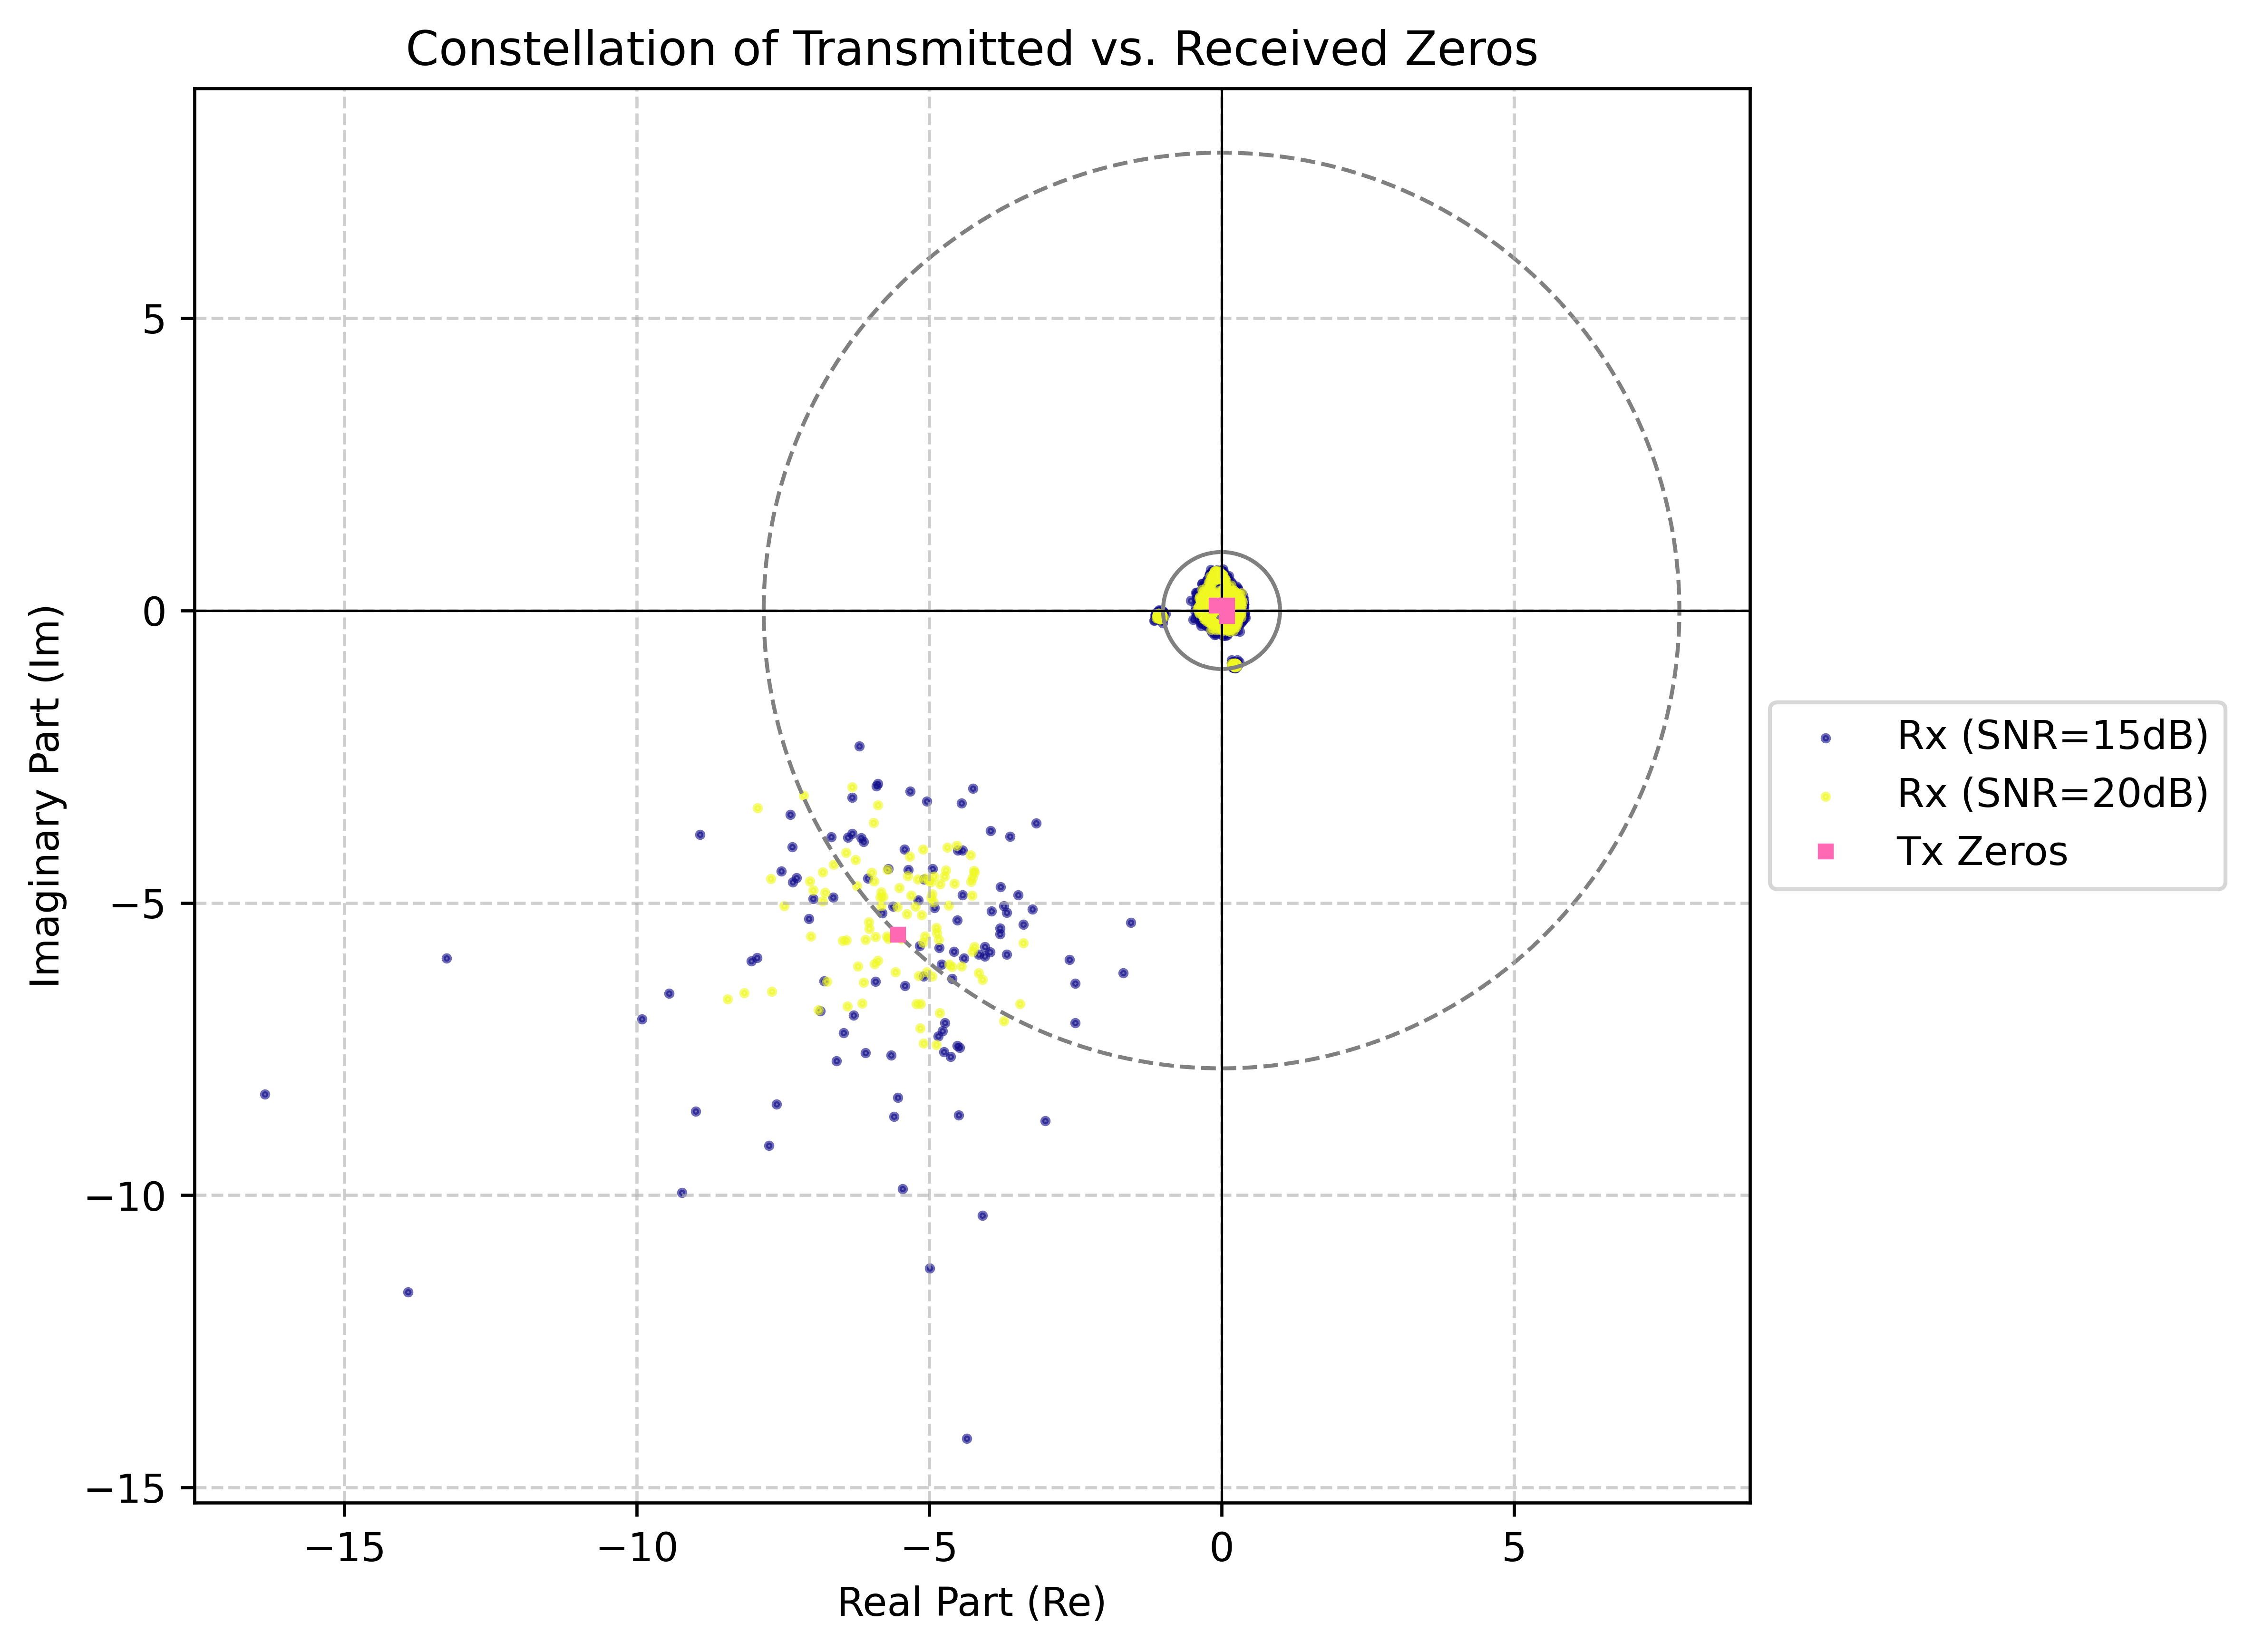

In [24]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=600) #

# Generate a list of distinct colors for the SNRs using a colormap
# 'plasma', 'viridis', or 'jet' work well for this
colors = plt.cm.plasma(np.linspace(0, 1, len(snr_range)))


for i, snr_db in enumerate(snr_range):
    rz = rx_zeros_dict[snr_db]
    ax.scatter(rz.real, rz.imag, color=colors[i], marker='.', s=10, 
               alpha=0.6, label=f'Rx (SNR={snr_db}dB)')

# zorder=5 forces these points to be drawn on TOP of the scatter plot
ax.plot(tx_zeros.real, tx_zeros.imag, marker='s', markerfacecolor='hotpink',
        markeredgecolor='hotpink', linestyle='none', markersize=3, 
        label='Tx Zeros', zorder=5)


circle1 = plt.Circle((0,0), radius=1, color='gray', fill=False, linestyle='-')
circle2 = plt.Circle((0,0), radius=Ri, color='gray', fill=False, linestyle='--')
circle3 = plt.Circle((0,0), radius=Ro, color='gray', fill=False, linestyle='--')

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

ax.set_aspect('equal', adjustable='box')

ax.axhline(0, color='black', linewidth=.6)
ax.axvline(0, color='black', linewidth=.6)

ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel('Real Part (Re)')
ax.set_ylabel('Imaginary Part (Im)')
ax.set_title('Constellation of Transmitted vs. Received Zeros')

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()